In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns   
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('raw_data/retail_transaction.csv')

print(f"Total raw lines loaded: {len(df)}")

Total raw lines loaded: 5000


In [3]:
df = df.dropna(subset=['CustomerID'])
print(f"Lines remaining after dropping missing IDs: {len(df)}\n")

Lines remaining after dropping missing IDs: 4850



In [4]:
import pandas as pd
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [5]:
evaluation_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (evaluation_date - x.max()).days,
    'InvoiceID': 'count',
    'PurchaseAmount' :'sum'
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']
print("--- Engine Aggregation Complete (First 5 Profiles) ---")
print(rfm.head())

--- Engine Aggregation Complete (First 5 Profiles) ---
  CustomerID  Recency  Frequency  Monetary
0  CUST_0001       18          6    298.94
1  CUST_0002       78          2    120.78
2  CUST_0003      184          2    101.80
3  CUST_0004       24          2    164.32
4  CUST_0005      346          1     20.43


In [7]:
features = ['Recency','Frequency','Monetary']
X = rfm[features]

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✔ Features successfully normalized. The dataset is ready for clustering spatial metrics.")

✔ Features successfully normalized. The dataset is ready for clustering spatial metrics.


In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print("=== MACHINE LEARNING ANALYSIS COMPLETE ===\n")
print("--- Average Core Metrics per Customer Persona Group ---")

print(rfm.groupby('Cluster')[features].mean())

print("\n--- Volume Breakdown per Cluster Group ---")
print(rfm['Cluster'].value_counts())

=== MACHINE LEARNING ANALYSIS COMPLETE ===

--- Average Core Metrics per Customer Persona Group ---
            Recency  Frequency    Monetary
Cluster                                   
0        191.136364   2.762626  129.311162
1         48.884696   4.188679  194.038763
2         45.236593   7.271293  427.049338

--- Volume Breakdown per Cluster Group ---
Cluster
1    477
2    317
0    198
Name: count, dtype: int64


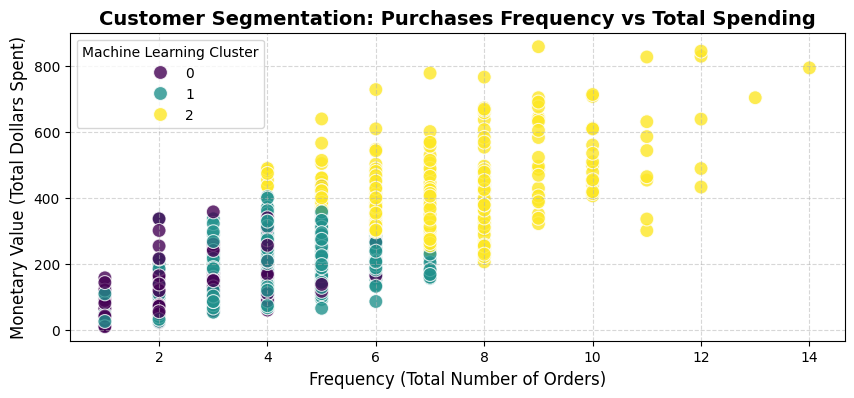

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns   
plt.figure(figsize=(10,4))

sns.scatterplot(
    data =rfm,
    x = 'Frequency',
    y ='Monetary',
    hue = 'Cluster',
    palette = 'viridis',
    s =100,
    alpha =0.8
)

plt.title('Customer Segmentation: Purchases Frequency vs Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Total Number of Orders)', fontsize=12)
plt.ylabel('Monetary Value (Total Dollars Spent)', fontsize=12)
plt.legend(title='Machine Learning Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

# business persona mapping

In [11]:
rfm['Persona'] = 'Unassigned'

for cluster_num in rfm['Cluster'].unique():
    cluster_df = rfm[rfm['Cluster'] == cluster_num]
    avg_monetary = cluster_df['Monetary'].mean()
    avg_recency = cluster_df['Recency'].mean()

    if avg_recency > rfm['Recency'].mean() * 1.2:
        rfm.loc[rfm['Cluster'] == cluster_num, 'Persona'] = 'Slipping/At-Risk Customers'
    elif avg_monetary > rfm['Monetary'].mean() * 1.2:
        rfm.loc[rfm['Cluster'] == cluster_num, 'Persona'] = 'VIP High-Spenders'
    else:
        rfm.loc[rfm['Cluster'] == cluster_num, 'Persona'] = 'Active General Shoppers'

print("--- Final E-Commerce Marketing Persona Directory ---")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Persona']].head(10))

rfm.to_csv('raw_data/final_customer_segments.csv', index=False)

--- Final E-Commerce Marketing Persona Directory ---
  CustomerID  Recency  Frequency  Monetary                     Persona
0  CUST_0001       18          6    298.94           VIP High-Spenders
1  CUST_0002       78          2    120.78     Active General Shoppers
2  CUST_0003      184          2    101.80  Slipping/At-Risk Customers
3  CUST_0004       24          2    164.32     Active General Shoppers
4  CUST_0005      346          1     20.43  Slipping/At-Risk Customers
5  CUST_0006       25          3    213.50     Active General Shoppers
6  CUST_0007      150          4    168.84  Slipping/At-Risk Customers
7  CUST_0008       69          6    302.30           VIP High-Spenders
8  CUST_0009       57          6    501.83           VIP High-Spenders
9  CUST_0010       42          8    262.77           VIP High-Spenders
